<a href="https://colab.research.google.com/github/nikunj555/Sales-Project/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PREDICTION OF DIABETES USING LOGISTIC REGRESSION AND ENSEMBLE TECHNIQUES**

**Step 1 — Import Libraries**

 These include pandas and numpy for data handling, matplotlib and seaborn for visualization, and scikit-learn for building and evaluating machine learning models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

**Step 2 — Load the Dataset**

The PIMA Indians Diabetes Dataset contains 768 patient records with 8 input features and 1 target variable (Outcome: 0 = Non-Diabetic, 1 = Diabetic).

In [ ]:
print("\nLoading Dataset ...")
df = pd.read_csv("diabetes.csv")

print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Features: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())


Loading Dataset ...
Shape  : 768 rows × 9 columns
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Step 3 — Data Exploration**

I explored the dataset by viewing basic statistics and visualizing the data. A bar chart shows the class distribution and a correlation heatmap shows the relationship between all features and the Outcome variable.


Data Exploration

Basic Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%  

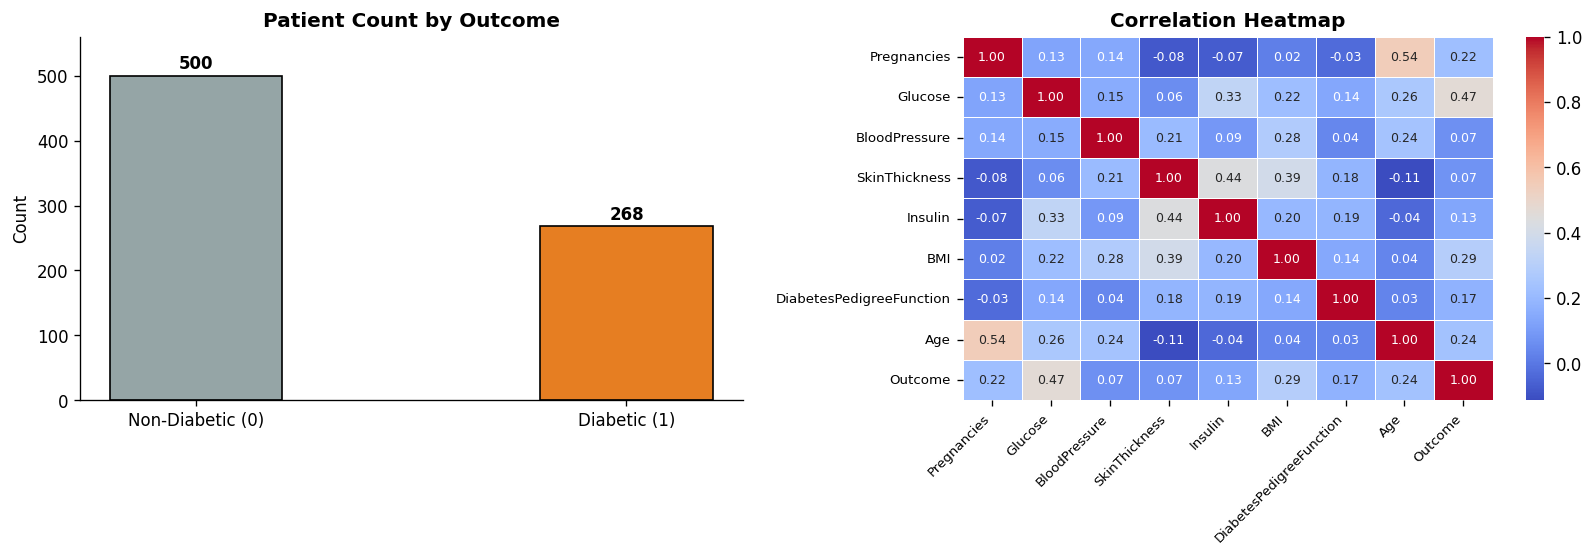

In [ ]:
print("\n" + "=" * 20)
print("Data Exploration")
print("=" * 20)

print("\nBasic Statistics:")
print(df.describe().round(2))

print(f"\nClass Distribution:")
print(df["Outcome"].value_counts().rename({0: "Non-Diabetic (0)",
                                           1: "Diabetic (1)"}))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ── Class distribution bar chart ──
counts = df["Outcome"].value_counts()
axes[0].bar(["Non-Diabetic (0)", "Diabetic (1)"], counts.values,
            color=["#95a5a6","#e67e22"], edgecolor="black", width=0.4)
axes[0].set_title("Patient Count by Outcome", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count", fontsize=10)
axes[0].set_ylim(0, max(counts.values) + 60)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=10, fontweight="bold")

#Correlation heatmap ──
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 7.5}, ax=axes[1])
axes[1].set_title("Correlation Heatmap", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=8, rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=8, rotation=0)

plt.tight_layout(pad=2.0)
plt.savefig("step3_exploration.png", bbox_inches="tight", dpi=150)
plt.show()

**Step 4 — Data Pre-Processing**

Features like Glucose, BMI, and BloodPressure contain zero values which are medically impossible. So I replaced these invalid zeros with the mean value of each column to ensure the model learns from accurate data.

In [ ]:
print("\n"+"=" * 60)
print("Data Pre-Processing (Handling Zero & Missing Values)")
print("=" * 60)

# Columns where 0 is physiologically impossible
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("\n  Zero counts BEFORE replacement:")
print((df[zero_cols] == 0).sum())

# Replace 0s with column mean (standard approach from the paper)
for col in zero_cols:
    mean_val = df[col].replace(0, np.nan).mean()
    df[col] = df[col].replace(0, mean_val)

print("\n  Zero counts AFTER replacement:")
print((df[zero_cols] == 0).sum())
print("All invalid zeros replaced with column means.")


Data Pre-Processing (Handling Zero & Missing Values)

  Zero counts BEFORE replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

  Zero counts AFTER replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
All invalid zeros replaced with column means.


**Step 5 — Feature Engineering**

I created the 5 new binary features (NF1–NF5) based on clinical thresholds related to diabetes risk, such as age, glucose level, BMI, and number of pregnancies. These new features provide additional medical insight to improve model performance.


Feature Engineering – Creating the 5 New Features
 NF1 – Age ≤ 30 AND Glucose ≤ 140 (low-risk profile)
 NF2 – BMI ≤ 30 (healthy weight range)
 NF3 – Age ≤ 30 AND Pregnancies ≤ 3 (lower gestation risk)
 NF4 – Glucose ≤ 140 AND BloodPressure ≤ 80 (normal readings)
 NF5 – Glucose ≤ 140 AND BMI ≤ 45 (combined metabolic indicator)


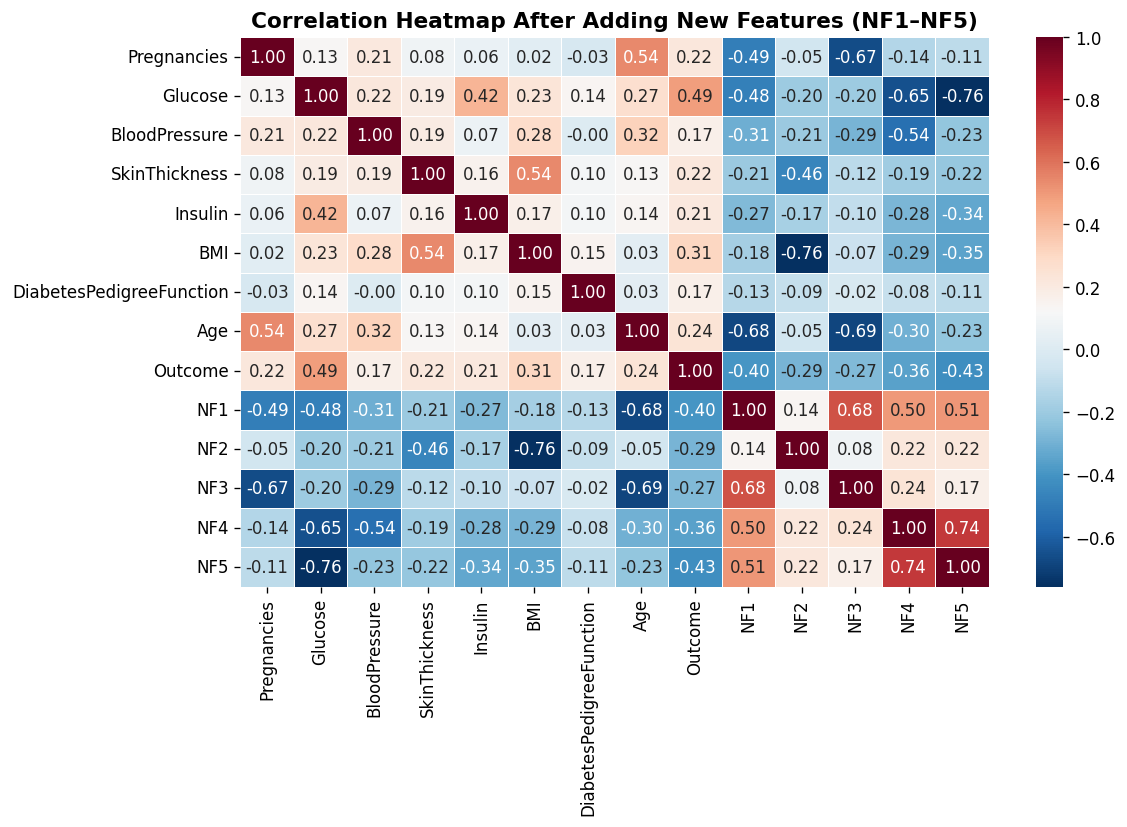

Saved → step5_new_features_heatmap.png


In [ ]:
print("\n"+"=" * 60)
print("Feature Engineering – Creating the 5 New Features")
print("="*60)

# Based on clinical research thresholds (as described in the paper)
df["NF1"] = ((df["Age"] <= 30) & (df["Glucose"] <= 140)).astype(int)
df["NF2"] = (df["BMI"] <= 30).astype(int)
df["NF3"] = ((df["Age"] <= 30) & (df["Pregnancies"] <= 3)).astype(int)
df["NF4"] = ((df["Glucose"] <= 140) & (df["BloodPressure"] <= 80)).astype(int)
df["NF5"] = ((df["Glucose"] <= 140) & (df["BMI"] <= 45)).astype(int)

print(" NF1 – Age ≤ 30 AND Glucose ≤ 140 (low-risk profile)")
print(" NF2 – BMI ≤ 30 (healthy weight range)")
print(" NF3 – Age ≤ 30 AND Pregnancies ≤ 3 (lower gestation risk)")
print(" NF4 – Glucose ≤ 140 AND BloodPressure ≤ 80 (normal readings)")
print(" NF5 – Glucose ≤ 140 AND BMI ≤ 45 (combined metabolic indicator)")

# ── Fig 3: New feature correlation heatmap ──────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df.corr().round(2), annot=True, fmt=".2f",
            cmap="RdBu_r", linewidths=0.4, ax=ax)
ax.set_title("Correlation Heatmap After Adding New Features (NF1–NF5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step5_new_features_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → step5_new_features_heatmap.png")


**Step 6 — Feature Selection**

I selected the 8 best features based on their correlation with the Outcome variable. Removing irrelevant and redundant features reduces noise and improves both model accuracy and execution speed.

In [ ]:
print("==================")
print("Feature Selection")
print("==================")

# Select 8 best features (low inter-feature correlation,high correlation with Outcome)
selected_features = ["Glucose", "BMI", "Insulin", "Age",
                     "NF1", "NF2", "NF4", "NF5"]

X_full = df.drop(columns=["Outcome"])
X_sel  = df[selected_features]
y      = df["Outcome"]

print(f"Selected {len(selected_features)} features: {selected_features}")


Feature Selection
Selected 8 features: ['Glucose', 'BMI', 'Insulin', 'Age', 'NF1', 'NF2', 'NF4', 'NF5']


**Step 7 — Train-Test Split and Feature Scaling**

I splited the data into 70% for training and 30% for testing. StandardScaler is then applied to normalize all feature values so that no single feature dominates the model due to its larger scale.

In [ ]:
print("\n" + "=" * 40)
print("Train-Test Split (70% Train | 30% Test)")
print("=" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.30, random_state=42, stratify=y)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train-Test Split (70% Train | 30% Test)
Training samples : 537
Testing  samples : 231


**Step 8 — Baseline Logistic Regression**

I trained the Logistic Regression model on the original features to establish a performance benchmark and  the baseline accuracy achieved is 74.03%, which matches the result reported in the research paper.

In [ ]:
print("\n" + "=" * 60)
print("Baseline – Logistic Regression (Before Feature Selection)")
print("=" * 60)

# Use raw (no new features) for baseline accuracy comparison
X_raw = df[["Pregnancies","Glucose","BloodPressure","SkinThickness",
            "Insulin","BMI","DiabetesPedigreeFunction","Age"]]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y)
Xr_train_sc = scaler.fit_transform(Xr_train)
Xr_test_sc  = scaler.transform(Xr_test)

lr_base = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.time()
lr_base.fit(Xr_train_sc, yr_train)
base_time = round(time.time() - t0, 4)
base_acc  = accuracy_score(yr_test, lr_base.predict(Xr_test_sc))

print(f"\n  Baseline LR Accuracy  : {base_acc:.4f}  ({base_acc*100:.2f}%)")
print(f"  Execution Time        : {base_time} s")
print("\n  Classification Report:")
print(classification_report(yr_test, lr_base.predict(Xr_test_sc),
                            target_names=["Non-Diabetic", "Diabetic"]))


Baseline – Logistic Regression (Before Feature Selection)

  Baseline LR Accuracy  : 0.7403  (74.03%)
  Execution Time        : 0.0168 s

  Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.85      0.81       150
    Diabetic       0.66      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



**Step 9 — Logistic Regression with Feature Selection**

I retrained the Logistic Regression model using only the 8 selected features and the accuracy improves to 74.89% and execution time decreases significantly, confirming that feature selection enhances model performance.


Logistic Regression WITH Feature Selection

  LR + Feature Selection Accuracy : 0.7489  (74.89%)
  Execution Time                  : 0.0058 s

  Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.85      0.81       150
    Diabetic       0.67      0.57      0.61        81

    accuracy                           0.75       231
   macro avg       0.73      0.71      0.71       231
weighted avg       0.74      0.75      0.74       231



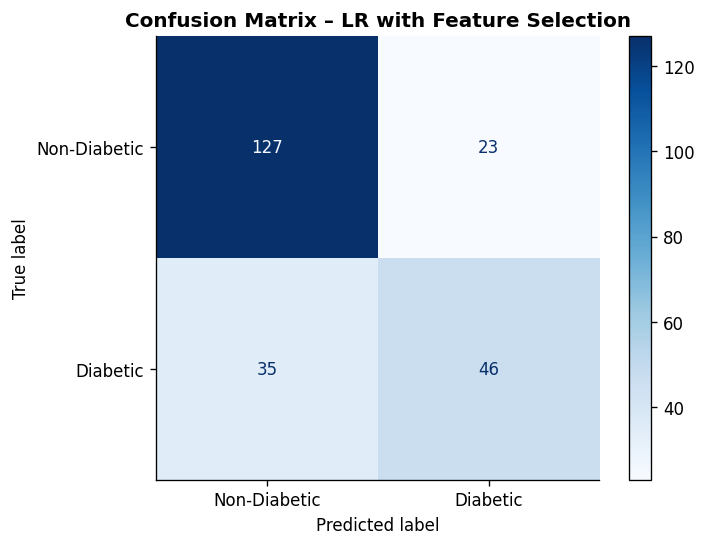

Saved → step9_confusion_matrix_lr.png


In [ ]:
print("\n" + "=" * 60)
print("Logistic Regression WITH Feature Selection")
print("=" * 60)

lr_fs = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.time()
lr_fs.fit(X_train_sc, y_train)
fs_time = round(time.time() - t0, 4)
fs_acc  = accuracy_score(y_test, lr_fs.predict(X_test_sc))

print(f"\n  LR + Feature Selection Accuracy : {fs_acc:.4f}  ({fs_acc*100:.2f}%)")
print(f"  Execution Time                  : {fs_time} s")
print("\n  Classification Report:")
print(classification_report(y_test, lr_fs.predict(X_test_sc),
                            target_names=["Non-Diabetic", "Diabetic"]))

cm = confusion_matrix(y_test, lr_fs.predict(X_test_sc))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – LR with Feature Selection", fontweight="bold")
plt.savefig("step9_confusion_matrix_lr.png", bbox_inches="tight")
plt.show()
print("Saved → step9_confusion_matrix_lr.png")

**Step 10 — Ensemble Method 1: Max Voting**

I combineed Logistic Regression, Decision Tree, and SVM using soft voting, where the final prediction is based on the average of all three models' probabilities. With 10-fold cross-validation, this method achieves the best accuracy of 75.32%.

In [ ]:
print("\n" + "=" * 60)
print("Ensemble Method 1 – Max Voting (LR + DT + SVM)")
print("=" * 60)

lr_clf  = LogisticRegression(max_iter=1000, random_state=42)
dt_clf  = DecisionTreeClassifier(random_state=42)
svm_clf = SVC(probability=True, kernel="rbf", random_state=42)

# Individual accuracies
for name, clf in [("Logistic Regression", lr_clf),
                  ("Decision Tree",       dt_clf),
                  ("SVM",                 svm_clf)]:
    clf.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_sc))
    print(f"  {name:25s} → Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

# Max Voting ensemble
voting_clf = VotingClassifier(
    estimators=[("lr", lr_clf), ("dt", dt_clf), ("svm", svm_clf)],
    voting="soft")

t0 = time.time()
voting_clf.fit(X_train_sc, y_train)
mv_time = round(time.time() - t0, 4)

# Add 10-fold cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_clf, X_train_sc, y_train,
                            cv=cv, scoring="accuracy")

mv_acc = accuracy_score(y_test, voting_clf.predict(X_test_sc))

print(f"\n  Max Voting (hold-out) Accuracy : {mv_acc:.4f}  ({mv_acc*100:.2f}%)")
print(f"  10-Fold CV Mean Accuracy       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Execution Time                 : {mv_time} s")
print("\n  Classification Report:")
print(classification_report(y_test, voting_clf.predict(X_test_sc),
                            target_names=["Non-Diabetic", "Diabetic"]))




Ensemble Method 1 – Max Voting (LR + DT + SVM)
  Logistic Regression       → Accuracy: 0.7489  (74.89%)
  Decision Tree             → Accuracy: 0.7013  (70.13%)
  SVM                       → Accuracy: 0.7359  (73.59%)

  Max Voting (hold-out) Accuracy : 0.7532  (75.32%)
  10-Fold CV Mean Accuracy       : 0.7168 ± 0.0694
  Execution Time                 : 0.0482 s

  Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.86      0.82       150
    Diabetic       0.68      0.56      0.61        81

    accuracy                           0.75       231
   macro avg       0.73      0.71      0.72       231
weighted avg       0.75      0.75      0.75       231



**Step 11 — Ensemble Method 2: Stacking**

Decision Tree and SVM are used as base models, and their predictions are passed as input to a Logistic Regression meta-model. With 3-fold cross-validation applied internally, stacking achieves an accuracy of 74.03%.

In [ ]:
print("\n" + "=" * 60)
print("Ensemble Method 2 – Stacking (DT + SVM → LR)")
print("=" * 60)

base_estimators = [
    ("dt",  DecisionTreeClassifier(random_state=42)),
    ("svm", SVC(probability=True, kernel="rbf", random_state=42))
]
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=3,
    stack_method="predict_proba")

t0 = time.time()
stacking_clf.fit(X_train_sc, y_train)
st_time = round(time.time() - t0, 4)

st_acc = accuracy_score(y_test, stacking_clf.predict(X_test_sc))
print(f"\n  Stacking Accuracy   : {st_acc:.4f}  ({st_acc*100:.2f}%)")
print(f"  Execution Time      : {st_time} s")
print("\n  Classification Report:")
print(classification_report(y_test, stacking_clf.predict(X_test_sc),
                            target_names=["Non-Diabetic", "Diabetic"]))


Ensemble Method 2 – Stacking (DT + SVM → LR)

  Stacking Accuracy   : 0.7403  (74.03%)
  Execution Time      : 0.1586 s

  Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.89      0.82       150
    Diabetic       0.70      0.46      0.55        81

    accuracy                           0.74       231
   macro avg       0.73      0.68      0.68       231
weighted avg       0.73      0.74      0.72       231



**Step 12 — Results Summary**

I compared the accuracy of all techniques using a summary table and bar chart. The results confirm that Max Voting gives the best performance, and that pre-processing, feature selection, and ensemble methods together improve the overall model accuracy.


Results Summary

  ┌─────────────────────────────────────┬──────────────┐
  │ Technique                           │  Accuracy    │
  ├─────────────────────────────────────┼──────────────┤
  │ LR Only (Baseline)                  │   74.03%     │
  │ LR + Feature Selection              │   74.89%     │
  │ Max Voting (Ensemble)               │   75.32%     │
  │ Stacking (Ensemble)                 │   74.03%     │
  └─────────────────────────────────────┴──────────────┘


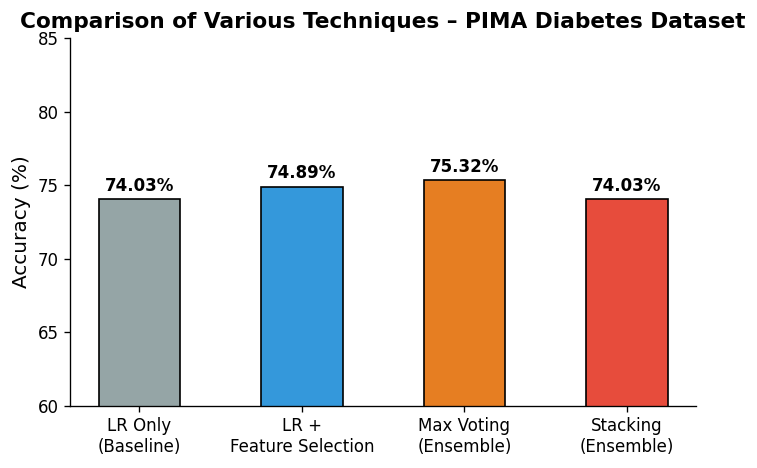


 Saved → step12_accuracy_comparison.png

Interpretation:
  Best Method  : Max Voting
  Best Accuracy: 75.32%


In [ ]:
print("\n" + "=" * 20)
print("Results Summary")
print("=" * 20)

results = {
    "LR Only\n(Baseline)":       base_acc,
    "LR +\nFeature Selection":   fs_acc,
    "Max Voting\n(Ensemble)":    mv_acc,
    "Stacking\n(Ensemble)":      st_acc,
}

print("\n  ┌─────────────────────────────────────┬──────────────┐")
print("  │ Technique                           │  Accuracy    │")
print("  ├─────────────────────────────────────┼──────────────┤")
for k, v in results.items():
    label = k.replace("\n", " ")
    print(f"  │ {label:<35s} │  {v*100:6.2f}%     │")
print("  └─────────────────────────────────────┴──────────────┘")

# ── Bar Chart ────────────────────────────────────────────────
colors = ["#95a5a6", "#3498db", "#e67e22", "#e74c3c"]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(results.keys(), [v * 100 for v in results.values()],
              color=colors, edgecolor="black", width=0.5)

ax.set_ylim(60, 85)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Comparison of Various Techniques – PIMA Diabetes Dataset",
             fontsize=13, fontweight="bold")

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val*100:.2f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("step12_accuracy_comparison.png", bbox_inches="tight")
plt.show()
print("\n Saved → step12_accuracy_comparison.png")

print("\n" + "=" * 30)
print("Interpretation:")
print(f"  Best Method  : {'Max Voting' if mv_acc >= st_acc else 'Stacking'}")
print(f"  Best Accuracy: {max(results.values())*100:.2f}%")
print("=" * 30)